In [ ]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from ultralytics import YOLO
import zipfile
import os
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()

Saving mobile phone detection.v1i.yolov11.zip to mobile phone detection.v1i.yolov11.zip


In [ ]:
zip_path = "/content/mobile phone detection.v1i.yolov11.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import yaml

yaml_path = "/content/dataset/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/dataset/train/images'
data['val'] = '/content/dataset/valid/images'
data['test'] = '/content/dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("YAML paths fixed")

YAML paths fixed


In [ ]:
model = YOLO("yolo11x.pt")

In [ ]:
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=120,
    imgsz=960,
    batch=8,
    patience=30,
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    weight_decay=0.0005,
    workers=4,
    device=0,
    cache=True,
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    perspective=0.0001,
    flipud=0.0,
    fliplr=0.5
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective=0.0001

In [ ]:
from ultralytics import YOLO
from google.colab import files
import cv2
import matplotlib.pyplot as plt

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
uploaded = files.upload()

Saving Screenshot (326).png to Screenshot (326).png


In [ ]:
results = model.predict(
    source="/content/Screenshot (326).png",
    conf=0.5,
    imgsz=640,
    save=True
)


image 1/1 /content/Screenshot (326).png: 384x640 1 cell-phone, 60.8ms
Speed: 2.4ms preprocess, 60.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


In [ ]:
print(model.names)

{0: 'cell-phone'}


(np.float64(-0.5), np.float64(1365.5), np.float64(767.5), np.float64(-0.5))

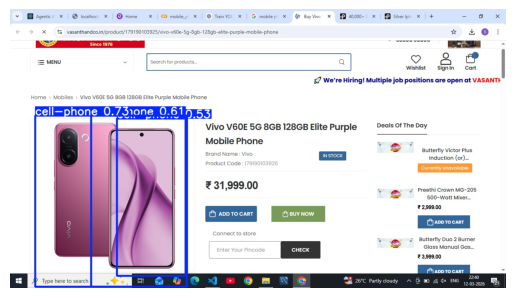

In [ ]:
import glob

result_path = glob.glob("/content/runs/detect/predict/*.jpg")[0]

img = cv2.imread(result_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")